## DC2 Galaxy Instructions

Here is a step-by-step list of how to download these data from the DESC. More information / the instructions I followed are found [here](https://data.lsstdesc.org/doc/dc2_sim_sky_survey).


1) First, we need to download the files. The DESC website has a Globus interface (once you make an account) for downloading the tables,
but for some reason I would get errors when I tried to download them this way. Luckily, they have a public Globus endpoint which you can access the 
normal way [here](https://app.globus.org/file-manager?origin_id=ed63cacc-514c-11eb-87b7-02187389bd35&origin_path=%2F&two_pane=false). The files you need are stored in the directory lsstdesc-public/dc2/run2.2i-dr6-v4/ . The folders the DESC website says to download are: truth_galaxy, truth_match, truth_sn, truth_star, object_dpdd. I don't think
we actually need all of them for our purpose, but I just downloaded all of them anyway. IMPORTANT: the full download of all these data was about 320 GB for me, so be cautious. The folders need to be downloaded in the same folder hierarchy that was on Globus. In other words, locally you need to have the following folder path: /{wherever you want the files locally}/lsstdesc-public/dc2/run2.2i-dr6-v4 , and download the files into run2.2i-dr6-v4 (I believe the DESC interface will automatically do this for you, but I was not able to get that working).


2) Once the files are downloaded, follow these [instructions](https://data.lsstdesc.org/doc/install_gcr) to download GCRCatalogs, which is the python module 
they have setup for loading in and working with the data. Note that after its installed you need to run `python -m GCRCatalogs.user_config set root_dir /path/to/the/download/directory` in the command line to tell GCRCatalogs where your files are stored (but you only need to do this once).


3) Once that is done, you should be able to run the cells below. More tutorials are provided in this Github [repo](https://github.com/LSSTDESC/desc-data-portal/tree/main/notebooks) for using GCRCatalogs. Here I just load in all of the galaxies from the truth table with $g < 27$ and plot them on the sky. There's about 77 million galaxies with $g < 27$ across the whole 300 deg $^2$ footprint. It takes about 1 minute to load it in on the machine I am using.


In [1]:
import GCRCatalogs
import GCRCatalogs
from GCRCatalogs.helpers.tract_catalogs import tract_filter, sample_filter
from GCRCatalogs import GCRQuery
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import angular_separation
from matplotlib.patches import Circle

In [2]:
GCRCatalogs.get_public_catalog_names()

['desc_cosmodc2',
 'desc_dc2_run2.2i_dr6_object',
 'desc_dc2_run2.2i_dr6_object_with_truth_match',
 'desc_dc2_run2.2i_dr6_truth',
 'desc_dc2_run2.2i_truth_galaxy_summary',
 'desc_dc2_run2.2i_truth_sn_summary',
 'desc_dc2_run2.2i_truth_sn_variability',
 'desc_dc2_run2.2i_truth_star_summary',
 'desc_dc2_run2.2i_truth_star_variability']

In [3]:
obj_cat = GCRCatalogs.load_catalog("desc_dc2_run2.2i_dr6_object")

In [4]:
sorted(obj_cat.list_all_quantities())

['I_flag',
 'I_flag_g',
 'I_flag_i',
 'I_flag_r',
 'I_flag_u',
 'I_flag_y',
 'I_flag_z',
 'IxxPSF_pixel',
 'IxxPSF_pixel_g',
 'IxxPSF_pixel_i',
 'IxxPSF_pixel_r',
 'IxxPSF_pixel_u',
 'IxxPSF_pixel_y',
 'IxxPSF_pixel_z',
 'Ixx_pixel',
 'Ixx_pixel_g',
 'Ixx_pixel_i',
 'Ixx_pixel_r',
 'Ixx_pixel_u',
 'Ixx_pixel_y',
 'Ixx_pixel_z',
 'IxyPSF_pixel',
 'IxyPSF_pixel_g',
 'IxyPSF_pixel_i',
 'IxyPSF_pixel_r',
 'IxyPSF_pixel_u',
 'IxyPSF_pixel_y',
 'IxyPSF_pixel_z',
 'Ixy_pixel',
 'Ixy_pixel_g',
 'Ixy_pixel_i',
 'Ixy_pixel_r',
 'Ixy_pixel_u',
 'Ixy_pixel_y',
 'Ixy_pixel_z',
 'IyyPSF_pixel',
 'IyyPSF_pixel_g',
 'IyyPSF_pixel_i',
 'IyyPSF_pixel_r',
 'IyyPSF_pixel_u',
 'IyyPSF_pixel_y',
 'IyyPSF_pixel_z',
 'Iyy_pixel',
 'Iyy_pixel_g',
 'Iyy_pixel_i',
 'Iyy_pixel_r',
 'Iyy_pixel_u',
 'Iyy_pixel_y',
 'Iyy_pixel_z',
 'blendedness',
 'cModelFluxErr_g',
 'cModelFluxErr_i',
 'cModelFluxErr_r',
 'cModelFluxErr_u',
 'cModelFluxErr_y',
 'cModelFluxErr_z',
 'cModelFlux_flag_g',
 'cModelFlux_flag_i',
 'cModel

In [5]:
quantities = ['ra', 'dec', 'mag_g_cModel', 'mag_r_cModel', 'mag_i_cModel',
              'mag_z_cModel']


## extendedness == 1 corresponds to galaxies
filters = [GCRQuery('extendedness == 1'), 
           GCRQuery((np.isfinite, 'mag_g_cModel')), 
           GCRQuery((np.isfinite, 'mag_r_cModel')),
           GCRQuery((np.isfinite, 'mag_i_cModel')),
           GCRQuery((np.isfinite, 'mag_z_cModel')),
           GCRQuery('mag_g_cModel < 27'),
           GCRQuery('mag_r_cModel < 27'),
           GCRQuery('mag_i_cModel < 27'),
           GCRQuery('mag_z_cModel < 27'), ## assign some magnitude cut to avoid very faint objects
           GCRQuery('clean')]


data =  obj_cat.get_quantities(quantities=quantities, filters=filters)

In [ ]:
## get all of the sources within 8 degrees of the center
in_circle = np.degrees(angular_separation(np.radians(data['ra']), np.radians(data['dec']), 
                               np.radians(np.median(data['ra'])), np.radians(np.median(data['dec'])))) < 8


## calculate the area of the sky covered by the circle with radius 8 degrees
sky_area = 2*np.pi*(1-np.cos(np.radians(8))) * (180/np.pi)**2

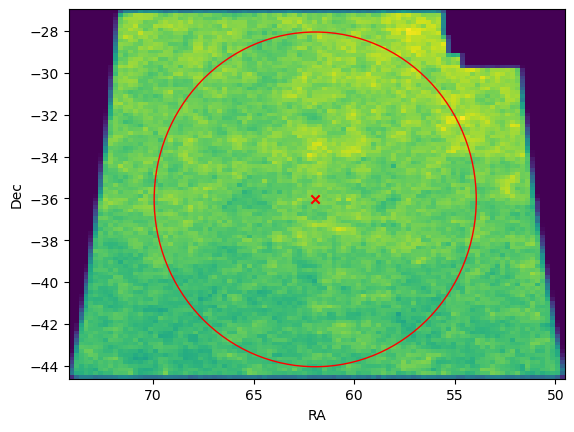

In [10]:
plt.hist2d(data['ra'], data['dec'], bins=100)
plt.xlabel('RA')
plt.ylabel('Dec')

plt.scatter(np.median(data['ra']), np.median(data['dec']), color='red', marker='x')

circle = Circle((np.median(data['ra']), np.median(data['dec'])), radius=8, edgecolor='red', facecolor='none')
plt.gca().add_patch(circle)

plt.gca().invert_xaxis()
plt.show()

If we want, we can take the approach of sampling a given region assuming a homogeneous spatial distribution and a magnitude
distribution based on the CDF of magnitudes within the circular region above:

In [ ]:
mag_bins = np.arange(14, 27, 0.5)
cdf = np.searchsorted(data["mag_g_cModel"], mag_bins, sorter=data["mag_g_cModel"].argsort())

Text(0, 0.5, 'Cumulative number per sq. deg')

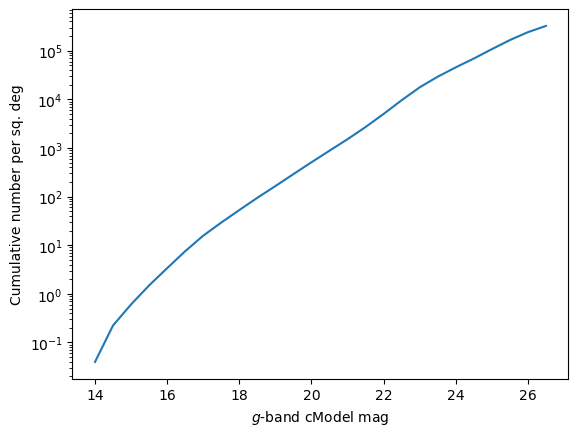

In [14]:
plt.semilogy(mag_bins, cdf / sky_area)
plt.xlabel("$g$-band cModel mag")
plt.ylabel("Cumulative number per sq. deg")

We could then assign the other magnitudes by fitting relations to g-mag as a function of r-mag with intrinsic scatter, which also increases 
as a function of g-mag:

Text(0, 0.5, 'r Mag')

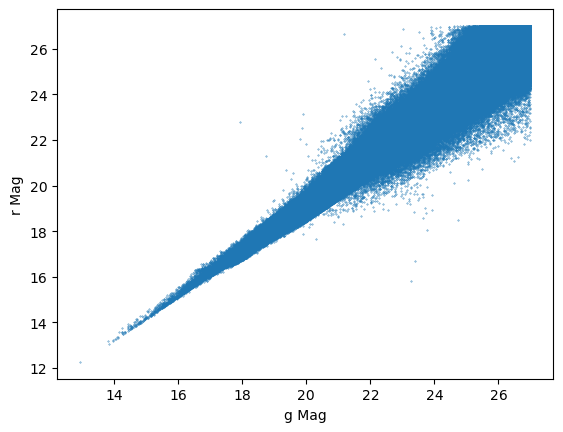

In [17]:
plt.scatter(data['mag_g_cModel'][in_circle], data['mag_r_cModel'][in_circle], s=0.1)

plt.xlabel("g Mag")
plt.ylabel("r Mag")